## Chatbots With Langgraph

In [1]:
!pip install langgraph langsmith


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install langchain langchain_groq langchain_community


   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ------


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import os
# Try to load environment variables from a .env file if it exists
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    print("python-dotenv not installed. Skipping .env loading.")

groq_api_key = os.getenv('groq_api_key')
langsmith = os.getenv('LANGSMITH_API_KEY')

# Optional: Check if keys were loaded
if not groq_api_key:
    print("Warning: groq_api_key not found in environment variables.")
if not langsmith:
    print("Warning: LANGSMITH_API_KEY not found in environment variables.")


In [8]:
import os
os.environ["LANGCHAIN_API_KEY"] = langsmith
os.environ["LANGCHAIN_TRACING_V2"]="true"
os.environ["LANGCHAIN_PROJECT"]="CourseLanggraph"

In [9]:
from langchain_groq import ChatGroq

In [22]:
llm = ChatGroq(model="llama-3.1-8b-instant")


## Start Building Chatbot Using Langgraph

In [11]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [12]:
class State(TypedDict):
  # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
  messages:Annotated[list,add_messages]

graph_builder=StateGraph(State)


In [13]:
graph_builder

In [14]:
def chatbot(state:State):
  return {"messages":llm.invoke(state['messages'])}

In [15]:
graph_builder.add_node("chatbot",chatbot)

In [16]:
graph_builder

In [17]:
graph_builder.add_edge(START,"chatbot")
graph_builder.add_edge("chatbot",END)

In [18]:
graph=graph_builder.compile()

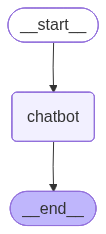

In [19]:
from IPython.display import Image, display
try:
  display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
  pass

In [23]:
while True:
  user_input=input("User: ")
  if user_input.lower() in ["quit","q"]:
    print("Good Bye")
    break
  for event in graph.stream({'messages':("user",user_input)}):
    print(event.values())
    for value in event.values():
      print(value['messages'])
      print("Assistant:",value["messages"].content)

dict_values([{'messages': AIMessage(content="**SQL (Structured Query Language)**\n\nSQL is a programming language designed for managing and manipulating data stored in relational database management systems (RDBMS). It is used to perform various operations such as creating, modifying, and querying databases.\n\n### Basic SQL Concepts\n\n#### 1. Data Types\n\n*   **Integer**: whole numbers, e.g., 1, 2, 3, etc.\n*   **Float**: decimal numbers, e.g., 3.14, -0.5, etc.\n*   **String**: text data, e.g., 'hello', 'world', etc.\n*   **Boolean**: true or false values\n*   **Date**: dates, e.g., '2022-01-01', etc.\n*   **Time**: times, e.g., '12:00:00', etc.\n\n#### 2. SQL Commands\n\n##### 1. **CREATE**\n\n*   **CREATE TABLE**: creates a new table in the database.\n*   **CREATE INDEX**: creates an index on a table column.\n*   **CREATE VIEW**: creates a virtual table based on the result of a query.\n\n```sql\nCREATE TABLE customers (\n    id INT PRIMARY KEY,\n    name VARCHAR(255),\n    email V